# Transfer Learning on CIFAR-10 using MobileNetV2
Input size: **96x96** (upsampled from 32x32)

MobileNetV2 is much lighter than ResNet50, making it a good choice for faster iteration or limited compute (e.g. Colab free tier).

# mount drive

In [1]:
import os
os.getcwd()

'/content'

In [2]:
MOUNT_PATH = "/content/drive/MyDrive/Ironhack_projects/"
DATASET_PATH = "/content/drive/MyDrive/Ironhack_projects/datasets"
MODEL_PATH = "/content/drive/MyDrive/Ironhack_projects/models"

In [3]:
from google.colab import drive
drive.mount('/content/drive')

print(os.getcwd())
os.listdir()

os.chdir(MOUNT_PATH)
print(os.getcwd())
#os.listdir()

Mounted at /content/drive
/content
/content/drive/MyDrive/Ironhack_projects


## 1. Imports

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import Sequential
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


## 2. Config

In [5]:
IMG_SIZE = 96
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS_HEAD = 5        # training just the new head
EPOCHS_FINE_TUNE = 10  # fine-tuning top layers of base model
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

## 3. Load CIFAR-10

In [6]:
# Load the data from drive
data = np.load("/content/drive/MyDrive/Ironhack_projects/datasets/cifar10.npz")

x_train_raw = data["x_train"]
y_train_raw = data["y_train"]
x_test_raw = data["x_test"]
y_test_raw = data["y_test"]

# Split training set into train and validation
x_train_raw, x_val_raw, y_train_raw, y_val_raw = train_test_split( x_train_raw, y_train_raw, test_size=0.2, random_state=42, stratify=y_train_raw)

print("Train shape:", x_train_raw.shape, y_train_raw.shape)
print("Val shape:  ", x_val_raw.shape, y_val_raw.shape)
print("Test shape: ", x_test_raw.shape, y_test_raw.shape)

Train shape: (40000, 32, 32, 3) (40000, 1)
Val shape:   (10000, 32, 32, 3) (10000, 1)
Test shape:  (10000, 32, 32, 3) (10000, 1)


In [7]:
#(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_val = to_categorical(y_val_raw, NUM_CLASSES)
y_test = to_categorical(y_test_raw, NUM_CLASSES)


## 4. Build `tf.data` pipeline
Resizes images to 96x96, applies augmentation on training data, and rescales using MobileNetV2's `preprocess_input` (scales pixels to the [-1, 1] range MobileNetV2 was trained with — this is the 'rescaling' step, more correct here than a plain `/255`).

In [8]:
def preprocess(image, label, training=False):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_crop(
            tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 8, IMG_SIZE + 8),
            size=[IMG_SIZE, IMG_SIZE, 3]
        )

    # Rescaling: MobileNetV2 expects preprocess_input (scales to [-1, 1])
    image = preprocess_input(image)
    return image, label


def make_dataset(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10000)
    ds = ds.map(lambda img, lbl: preprocess(img, lbl, training=training),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(x_train_raw, y_train, training=True)
val_ds = make_dataset(x_val_raw, y_val, training=False)
test_ds = make_dataset(x_test_raw, y_test, training=False)


## 5. Build the model
Load MobileNetV2 without its top classification layer, freeze it, and attach a new head for 10 classes.

In [9]:
from keras.backend import clear_session
clear_session()

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False  # freeze base initially

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 3, 3, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,014,794 (11.50 MB)

 Trainable params: 756,682 (2.89 MB)

 Non-trainable params: 2,258,112 (8.61 MB)

## 6. Callbacks
Early stopping and LR reduction help avoid wasted epochs and overfitting.

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]


## 7. Phase 1 — Train the new head (base frozen)

In [11]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 47ms/step - accuracy: 0.8130 - loss: 0.5546 - val_accuracy: 0.8485 - val_loss: 0.4342 - learning_rate: 0.0010
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8461 - loss: 0.4400 - val_accuracy: 0.8362 - val_loss: 0.4722 - learning_rate: 0.0010
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8574 - loss: 0.4041 - val_accuracy: 0.8660 - val_loss: 0.3921 - learning_rate: 0.0010
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8691 - loss: 0.3756 - val_accuracy: 0.8584 - val_loss: 0.4089 - learning_rate: 0.0010
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.8755 - loss: 0.3524 - val_accuracy: 0.8694 - val_loss: 0.3876 - learning_rate: 0.0010


## 8. Phase 2 — Fine-tune top layers of MobileNetV2
Unfreeze the last ~30 layers and continue training with a much lower learning rate so we don't destroy the pretrained weights.

In [12]:
base_model.trainable = True

# Freeze all layers except the last ~30
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step - accuracy: 0.8280 - loss: 0.5076 - val_accuracy: 0.8697 - val_loss: 0.4067 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8629 - loss: 0.4019 - val_accuracy: 0.8758 - val_loss: 0.3729 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8766 - loss: 0.3631 - val_accuracy: 0.8792 - val_loss: 0.3617 - learning_rate: 1.0000e-05
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8819 - loss: 0.3335 - val_accuracy: 0.8781 - val_loss: 0.3594 - learning_rate: 1.0000e-05
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8906 - loss: 0.3147 - val_accuracy: 0.8818 - val_loss: 0.3518 - learning_rate: 1.0000e-05
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.8953 - loss: 0.2931 - val_accuracy: 0.8835 - val_loss: 0.3444 - learning_rate: 1.0000e-05
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/ste

## 9. Plot training curves

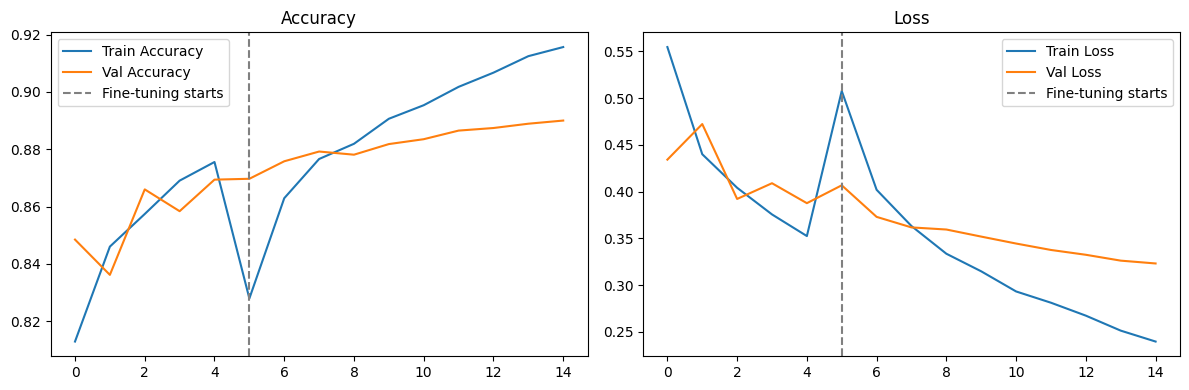

In [13]:
import matplotlib.pyplot as plt

acc = history_head.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_head.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss_hist = history_head.history['loss'] + history_finetune.history['loss']
val_loss_hist = history_head.history['val_loss'] + history_finetune.history['val_loss']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(EPOCHS_HEAD, color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss_hist, label='Train Loss')
plt.plot(val_loss_hist, label='Val Loss')
plt.axvline(EPOCHS_HEAD, color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()


## 10. Evaluate

In [14]:

loss_v, accuracy_v = model.evaluate(val_ds)
print(f"Final VAL Accuracy: {accuracy_v:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8900 - loss: 0.3231
Final VAL Accuracy: 0.8900


## 11. Save model

In [15]:
model.save(MODEL_PATH+ 'mobilenetv2_transfer.keras')
print("Model saved as mobilenetv2_transfer.keras")


Model saved as mobilenetv2_transfer.keras
